In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv("/content/drive/MyDrive/Datasets/stocks (1).csv")

In [4]:
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,07-02-2023,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,08-02-2023,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,09-02-2023,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,10-02-2023,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,13-02-2023,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,01-05-2023,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,02-05-2023,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,03-05-2023,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,04-05-2023,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177506,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


In [7]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
243,False
244,False
245,False
246,False


In [8]:
df.isnull().sum()

,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [9]:
df.shape

(248, 8)

Exploratory Dara Analysis

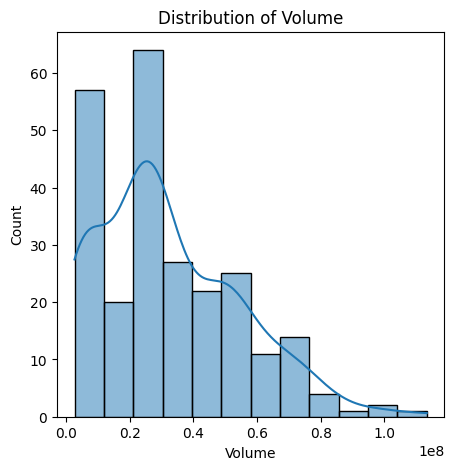

In [10]:
plt.figure(figsize = (5,5))
sns.histplot(df['Volume'], kde = True)
plt.title("Distribution of Volume")
plt.show()

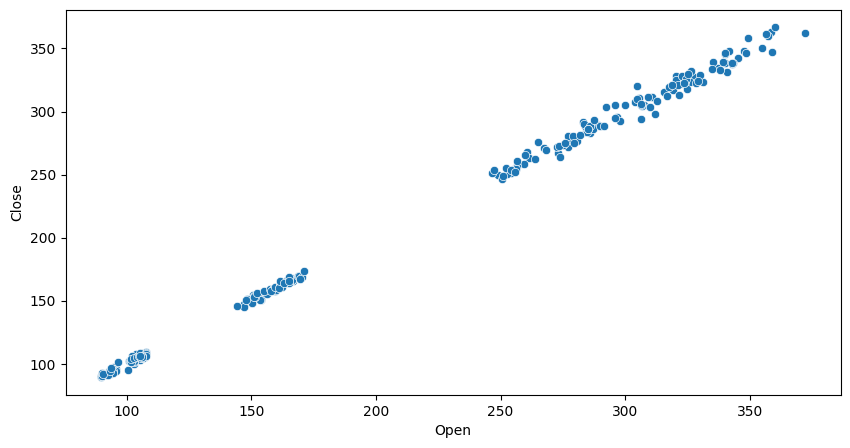

In [11]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df, x = 'Open', y = 'Close')
plt.show()

<Axes: >

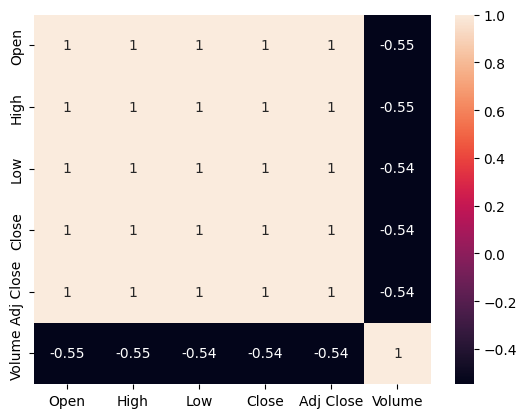

In [12]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot = True)


Pair Plot

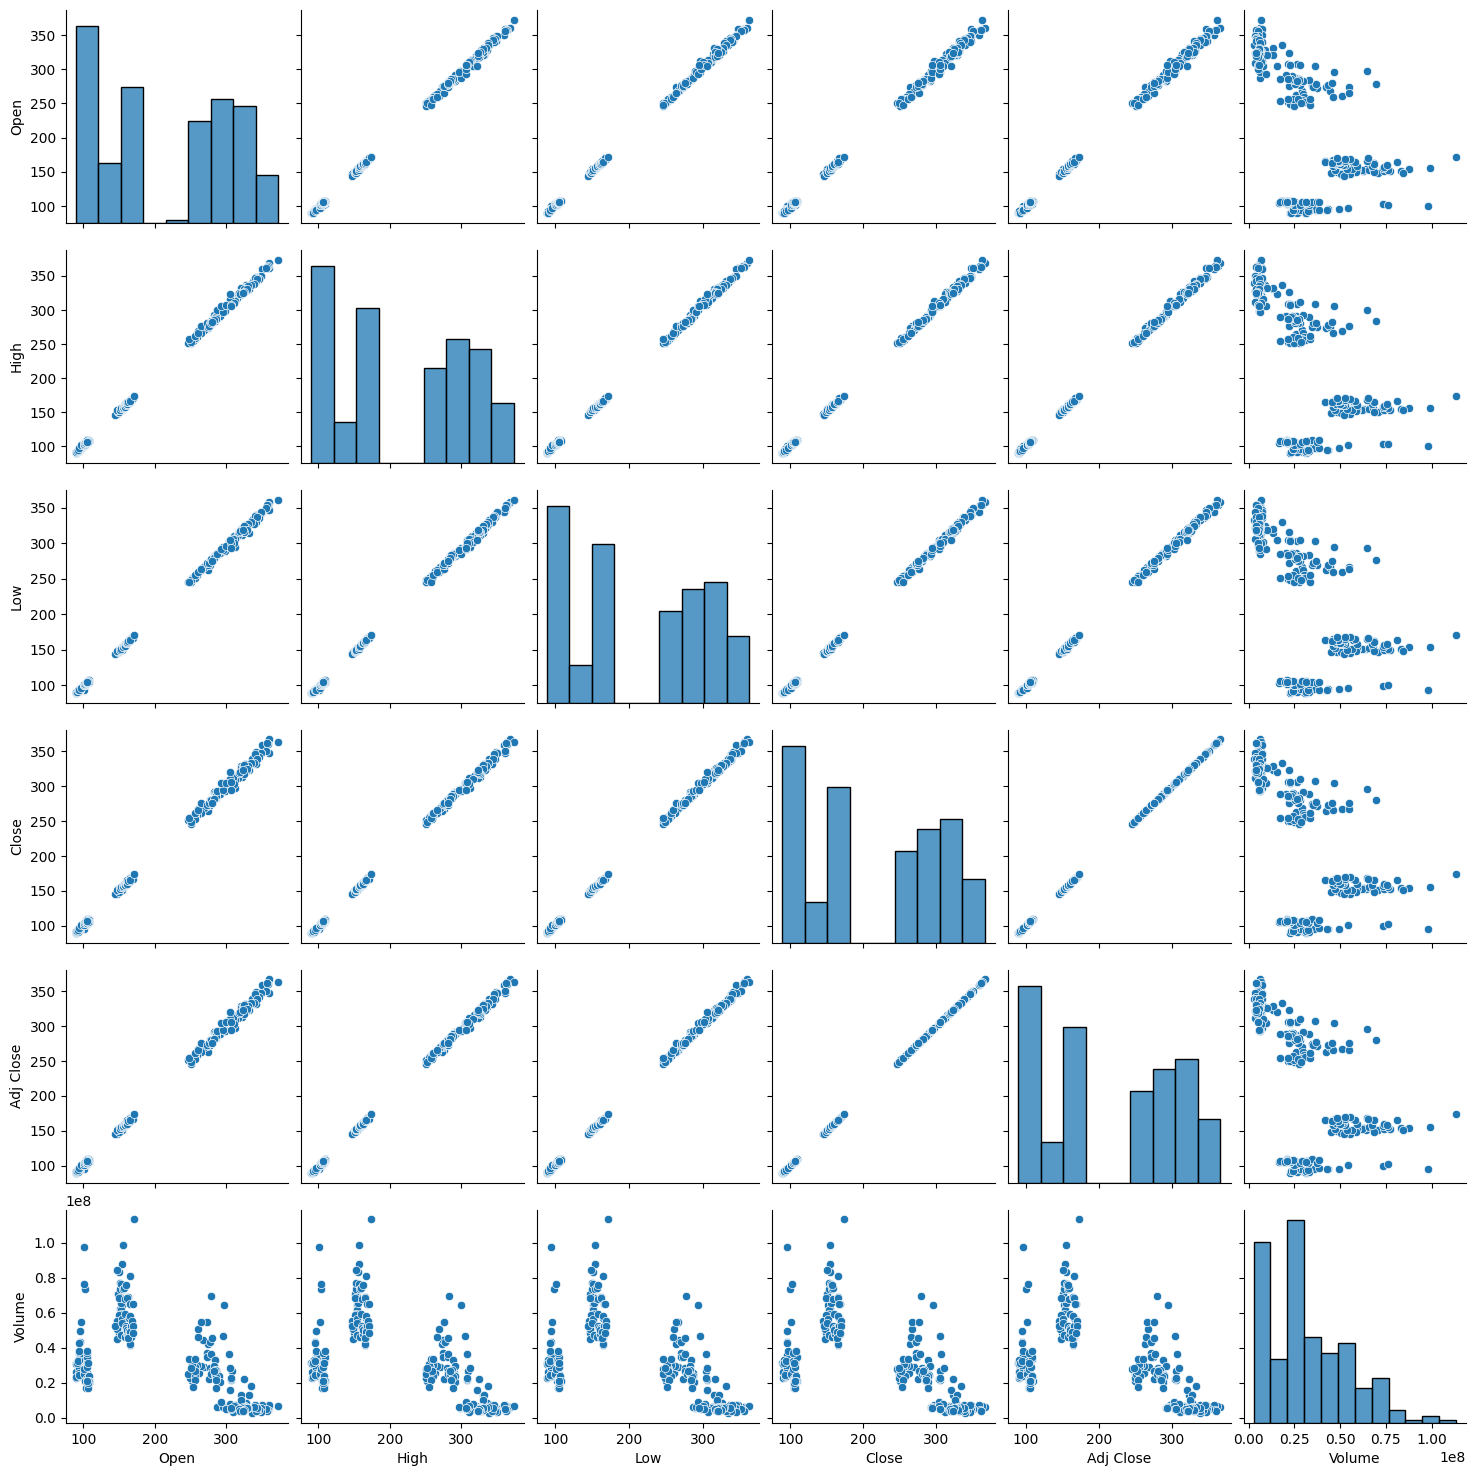

In [13]:
sns.pairplot(df)

Check Outliers in the Open Column :-

<Axes: xlabel='Open'>

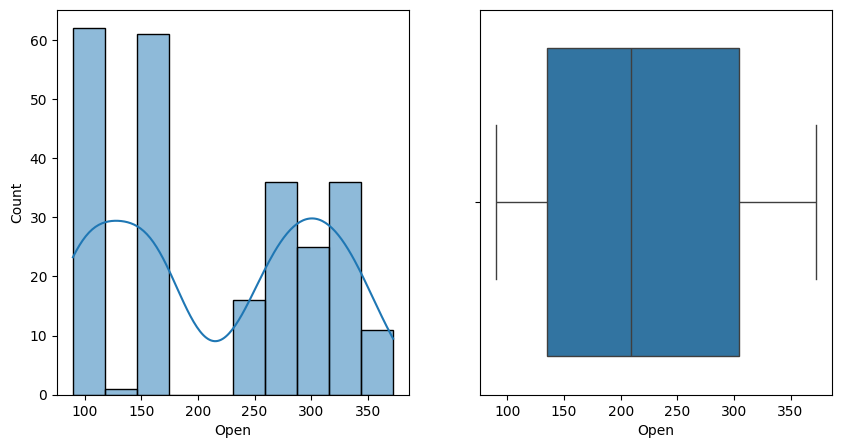

In [14]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Open'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Open'])

Check Outliers in the High Column.

<Axes: xlabel='High'>

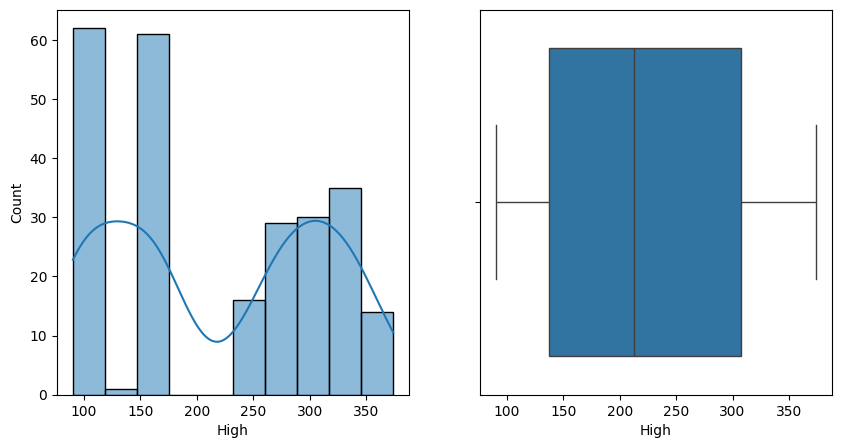

In [15]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['High'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['High'])

Check Outliers in the Low Column.

<Axes: xlabel='Low'>

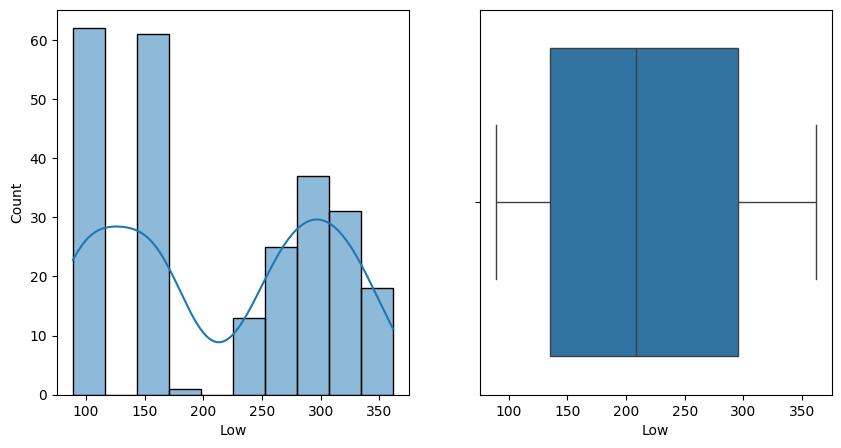

In [16]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Low'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Low'])

Check Outliers in the Close Column.

<Axes: xlabel='Close'>

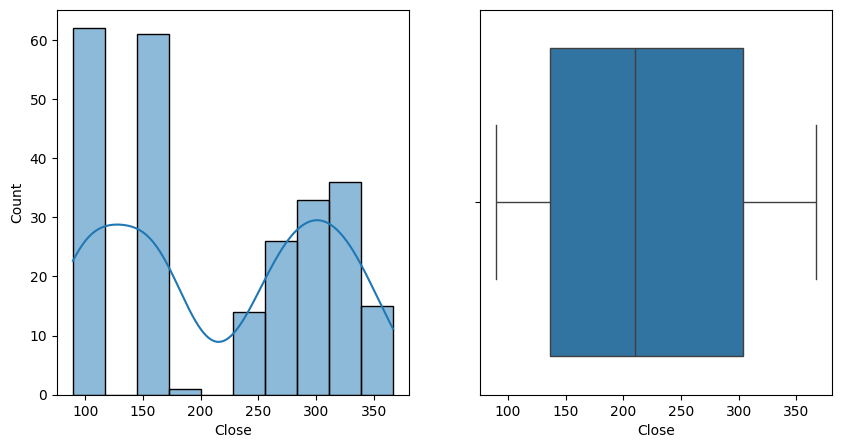

In [17]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Close'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Close'])

Check outliers in the Adj Close Column.

<Axes: xlabel='Adj Close'>

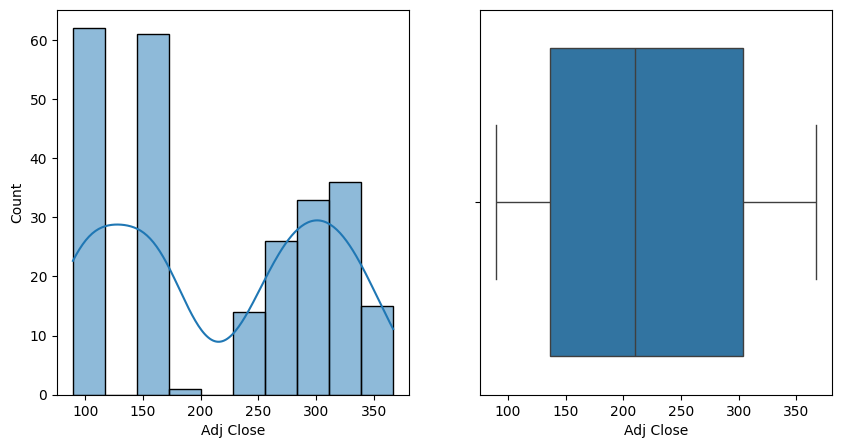

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Adj Close'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Adj Close'])


Check Outliers in the Volume Column.

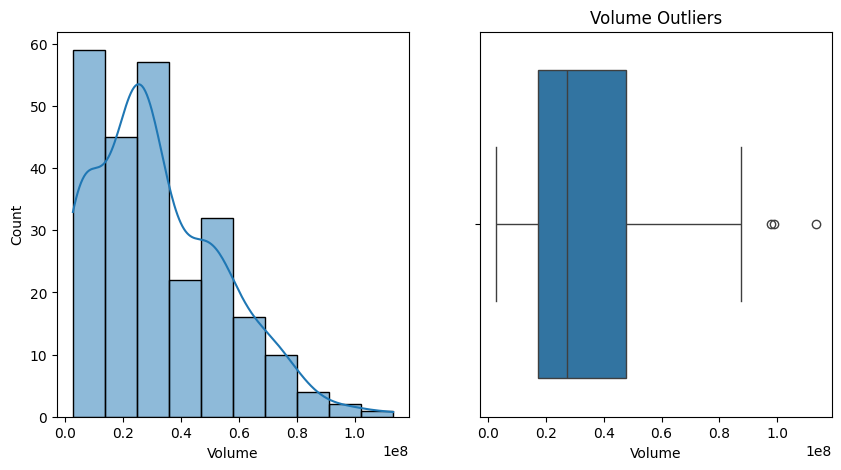

In [19]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Volume'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Volume'])
plt.title("Volume Outliers")
plt.show()

Remove Outliers from IQR Method in the Volume column.

In [20]:
percentile25 = df['Volume'].quantile(0.25)
percentile75 = df['Volume'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 17141800.0
Percentile75 = 47717725.0


In [21]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

IQR = 30575925.0


In [22]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

Upper Limit = 93581612.5
Lower Limit = -28722087.5


In [23]:
df[df['Volume'] > upper_limit]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
27,AAPL,17-03-2023,156.080002,156.740005,154.279999,155.000000,155.000000,98944600
61,AAPL,05-05-2023,170.979996,174.300003,170.759995,173.570007,173.570007,113316400
188,GOOG,09-02-2023,100.540001,100.610001,93.860001,95.459999,95.459999,97798600


In [24]:
df[df['Volume'] < lower_limit]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume


Trimming

In [25]:
new_df = df[(df['Volume'] < upper_limit) & (df['Volume'] > lower_limit)]

In [26]:
new_df.shape

(245, 8)

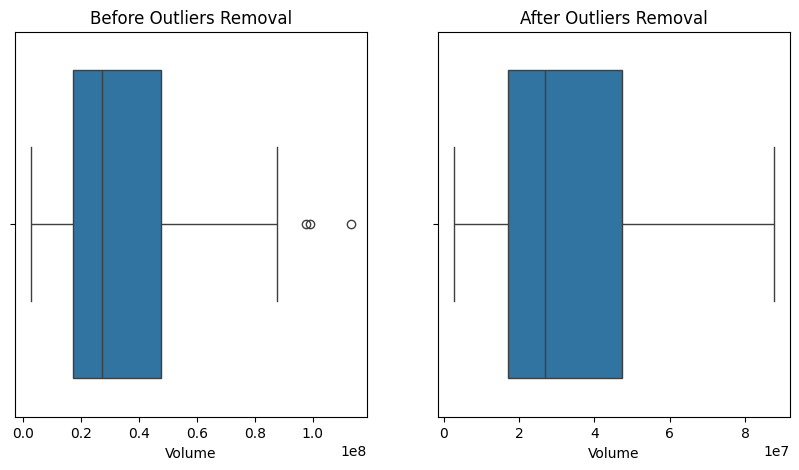

In [27]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x = df['Volume'])
plt.title("Before Outliers Removal")

plt.subplot(1,2,2)
sns.boxplot(x = new_df['Volume'])
plt.title("After Outliers Removal")
plt.show()

Create Dummy Variable.

In [28]:
df_clean = pd.get_dummies(new_df,columns = ['Ticker'])
df_clean

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker_AAPL,Ticker_GOOG,Ticker_MSFT,Ticker_NFLX
0,07-02-2023,150.639999,155.229996,150.639999,154.649994,154.414230,83322600,True,False,False,False
1,08-02-2023,153.880005,154.580002,151.169998,151.919998,151.688400,64120100,True,False,False,False
2,09-02-2023,153.779999,154.330002,150.419998,150.869995,150.639999,56007100,True,False,False,False
3,10-02-2023,149.460007,151.339996,149.220001,151.009995,151.009995,57450700,True,False,False,False
4,13-02-2023,150.949997,154.259995,150.919998,153.850006,153.850006,62199000,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
243,01-05-2023,107.720001,108.680000,107.500000,107.709999,107.709999,20926300,False,True,False,False
244,02-05-2023,107.660004,107.730003,104.500000,105.980003,105.980003,20343100,False,True,False,False
245,03-05-2023,106.220001,108.129997,105.620003,106.120003,106.120003,17116300,False,True,False,False
246,04-05-2023,106.160004,106.300003,104.699997,105.209999,105.209999,19780600,False,True,False,False


In [29]:
new_df.shape

(245, 8)

In [30]:
X = df_clean.drop(["Volume","Date"], axis = 1)
y = df_clean[["Volume"]]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_predict = model.predict(X_test)

In [34]:
accuracy = r2_score(y_test, y_predict)
print(f"Final Model Accuracy (R-squared): {accuracy:.2f}")

Final Model Accuracy (R-squared): 0.85


In [35]:
print(model.score(X_train, y_train))

0.8136249523415535


In [36]:
print(model.score(X_test, y_test))

0.8487729132822198


In [37]:
n = int(input("Enter the prediction row number = "))
test_value = X_test.iloc[n]
real_value = y_test.iloc[n]
prediction = model.predict([test_value])
defference = abs(real_value[0] - prediction[0][0])
print(f"Prediction Row Number {n} Result")
print(f"Real Value = {real_value[0]:.2f}")
print(f"Prediction Volumetric Value = {prediction[0][0]:.2f}")
print(f"Difference = {defference:.2f}")

Enter the prediction row number = 7
Prediction Row Number 7 Result
Real Value = 6901100.00
Prediction Volumetric Value = 6532331.61
Difference = 368768.39
